In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/dragonheir/logistic-regression/Social_Network_Ads.csv


## DATA OVERVIEW

In [2]:
df=pd.read_csv('/kaggle/input/datasets/dragonheir/logistic-regression/Social_Network_Ads.csv')
df

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0
...,...,...,...,...,...
395,15691863,Female,46,41000,1
396,15706071,Male,51,23000,1
397,15654296,Female,50,20000,1
398,15755018,Male,36,33000,0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   User ID          400 non-null    int64 
 1   Gender           400 non-null    object
 2   Age              400 non-null    int64 
 3   EstimatedSalary  400 non-null    int64 
 4   Purchased        400 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 15.8+ KB


In [4]:
df.describe()

,User ID,Age,EstimatedSalary,Purchased
count,4.000000e+02,400.000000,400.000000,400.000000
mean,1.569154e+07,37.655000,69742.500000,0.357500
std,7.165832e+04,10.482877,34096.960282,0.479864
min,1.556669e+07,18.000000,15000.000000,0.000000
25%,1.562676e+07,29.750000,43000.000000,0.000000
50%,1.569434e+07,37.000000,70000.000000,0.000000
75%,1.575036e+07,46.000000,88000.000000,1.000000
max,1.581524e+07,60.000000,150000.000000,1.000000


In [5]:
df.duplicated().sum()

np.int64(0)

In [6]:
df.isnull().sum()

User ID            0
Gender             0
Age                0
EstimatedSalary    0
Purchased          0
dtype: int64

## EDA

In [7]:
df['Purchased'].value_counts()

Purchased
0    257
1    143
Name: count, dtype: int64

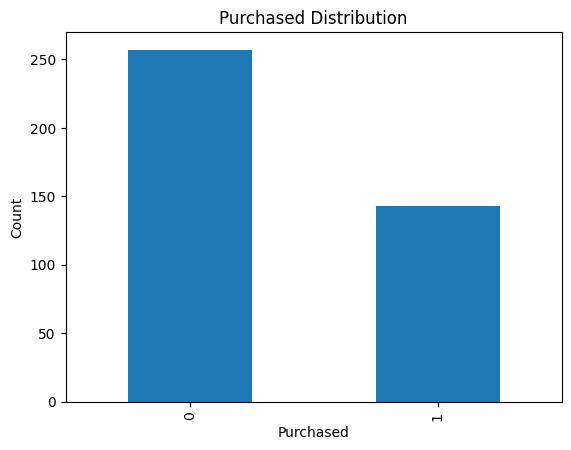

In [8]:
df['Purchased'].value_counts().plot(kind='bar')
plt.title("Purchased Distribution")
plt.xlabel("Purchased")
plt.ylabel("Count")
plt.show()

**The dataset more entries about people who have not made the purchase than it's counterpart.**

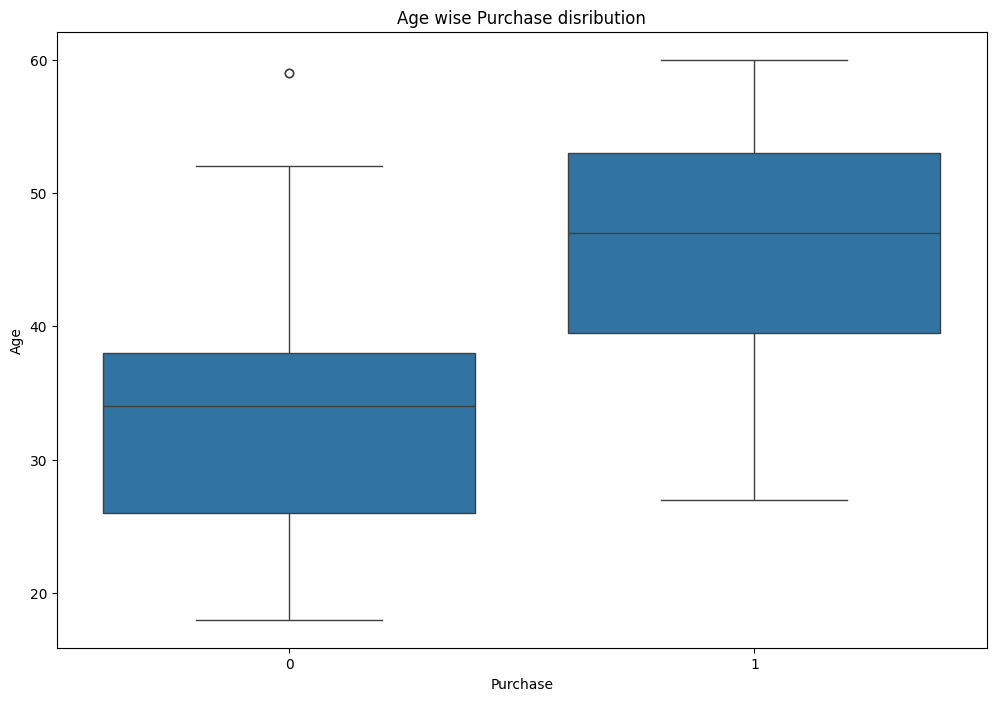

In [9]:
plt.figure(figsize=(12,8))
sns.boxplot(data=df, x='Purchased',y='Age')
plt.title('Age wise Purchase disribution')
plt.xlabel('Purchase')
plt.ylabel('Age')
plt.show()

**Hence it is visible from the graph that, ages between 40 and 55 are more susceptible to making the purchase than the younger ages. Hence, age is a good factor to make predictions on purchase.**

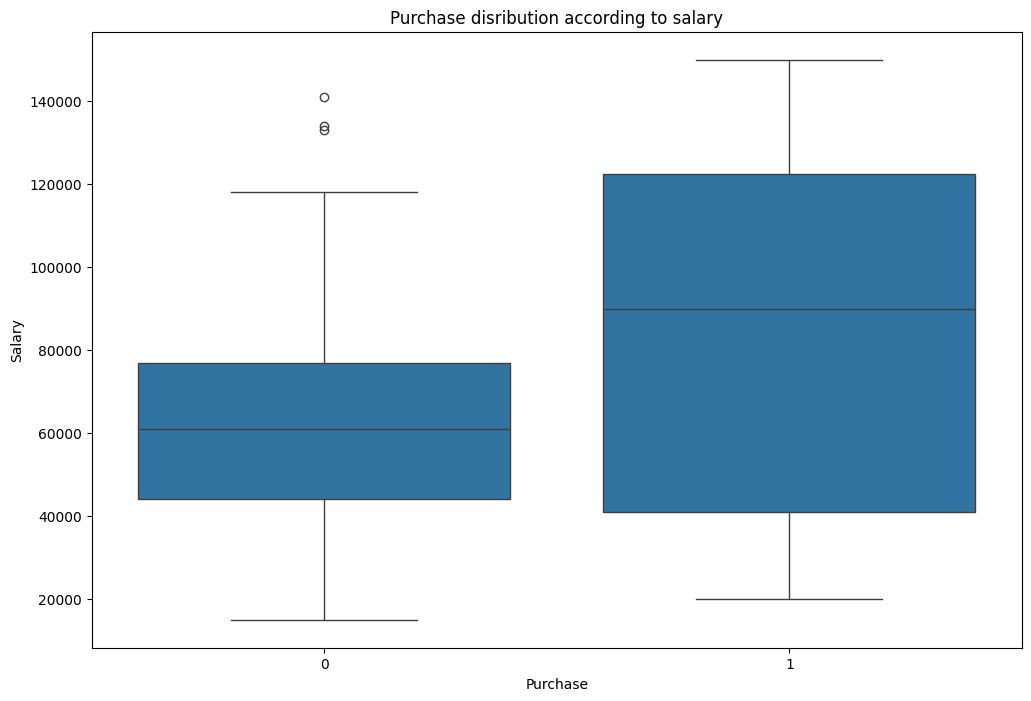

In [10]:
plt.figure(figsize=(12,8))
sns.boxplot(data=df, x='Purchased',y='EstimatedSalary')
plt.title('Purchase disribution according to salary')
plt.xlabel('Purchase')
plt.ylabel('Salary')
plt.show()

**The observations of both purchase groups by salary overlap too much, hence it may not be good for making predictions by itself. It may still be used in conjunction with another.**

In [11]:
df['User ID'].nunique()

400

In [12]:
df['Gender'].value_counts()

Gender
Female    204
Male      196
Name: count, dtype: int64

**More number of female entries than male.**

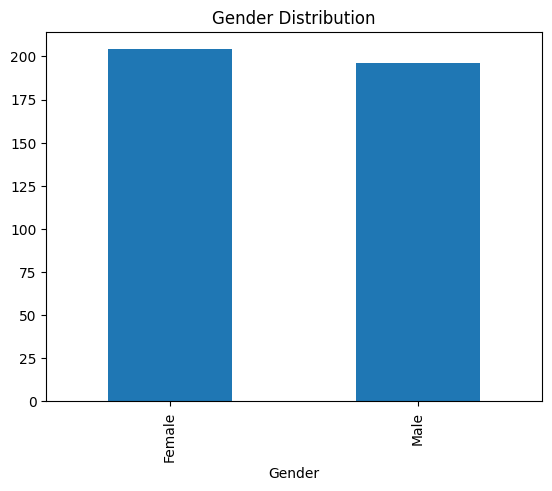

In [13]:
df['Gender'].value_counts().plot(kind='bar')
plt.title("Gender Distribution")
plt.show()

**The dataset contains more information about females than males. We observe further to understand whether they affect purchase or not.**

In [14]:
df.groupby('Purchased')[['Age','EstimatedSalary']].mean()

,Age,EstimatedSalary
Purchased,,
0,32.793774,60544.747082
1,46.391608,86272.727273


In [15]:
df.groupby('Age')[['EstimatedSalary','Purchased']].mean()

,EstimatedSalary,Purchased
Age,,
18,66400.000000,0.000000
19,46000.000000,0.000000
20,61714.285714,0.000000
21,61000.000000,0.000000
22,48800.000000,0.000000
23,51166.666667,0.000000
24,49111.111111,0.000000
25,65166.666667,0.000000
26,53500.000000,0.000000


**Average salary and purchase based on age group.**

In [16]:
pd.crosstab(df['Gender'], df['Purchased'])

Purchased,0,1
Gender,,
Female,127,77
Male,130,66


<Axes: xlabel='Gender'>

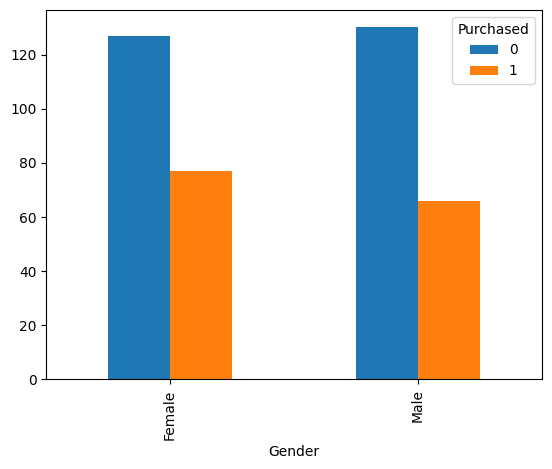

In [17]:
pd.crosstab(df['Gender'], df['Purchased']).plot(kind='bar')

<Axes: >

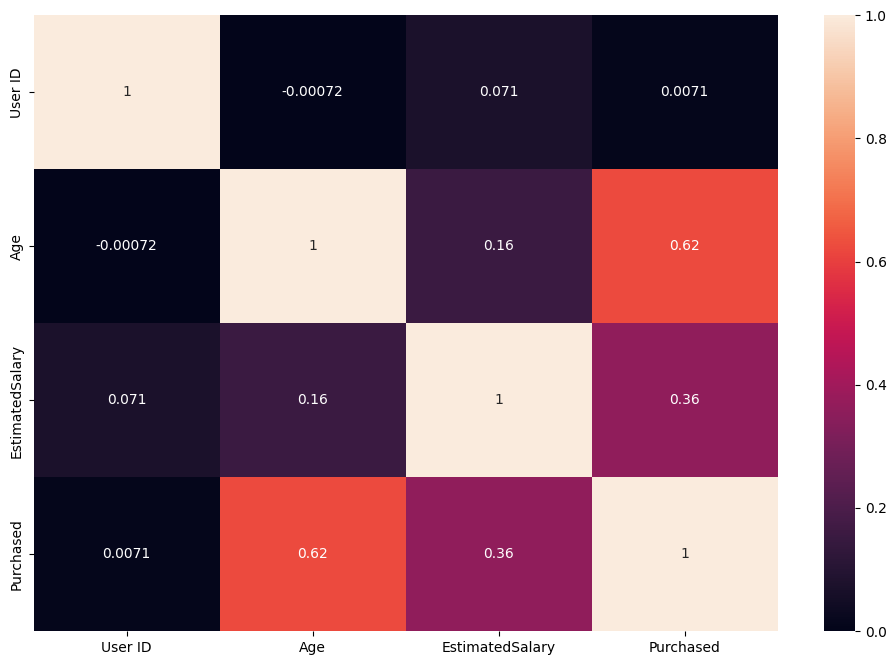

In [18]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True), annot=True)

**Purchased and Age have a good level of correlation, hence it can be used to classify purchase.**

<Axes: >

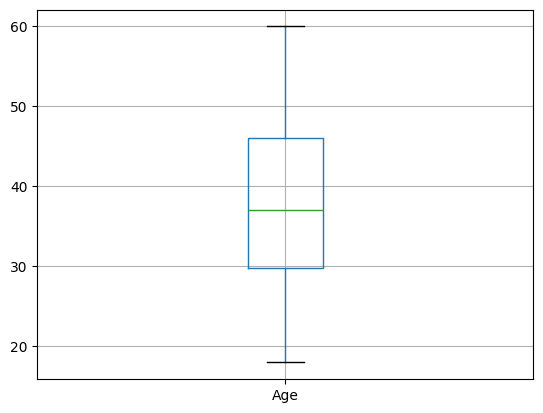

In [19]:
df.boxplot('Age')

<Axes: >

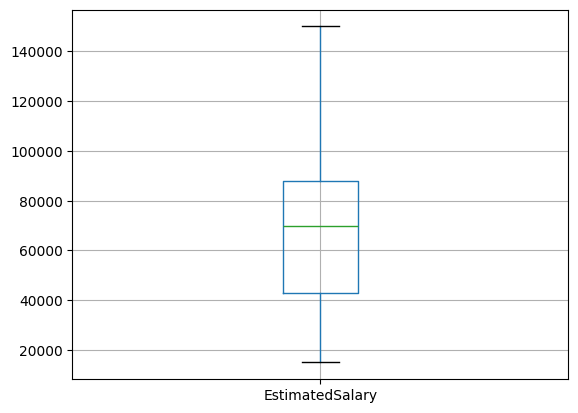

In [20]:
df.boxplot('EstimatedSalary')

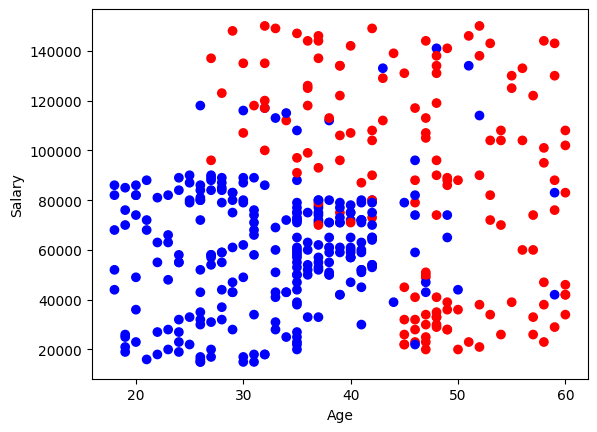

In [21]:
colors = df['Purchased'].map({0:'blue',1:'red'})
plt.scatter(df['Age'], df['EstimatedSalary'], c=colors)
plt.xlabel("Age")
plt.ylabel("Salary")
plt.show()

In [22]:
columns = ['User ID','Age','EstimatedSalary','Purchased']

for col in columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    if lower<0:
        lower=0
    outliers = df[(df[col] < lower) | (df[col] > upper)]

    print(f"{col}")
    print(f"Normal range: {lower:.2f} to {upper:.2f}")
    print(f"Outliers: {len(outliers)} ({len(outliers)/len(df)*100:.2f}%)\n")

User ID
Normal range: 15441364.88 to 15935761.88
Outliers: 0 (0.00%)

Age
Normal range: 5.38 to 70.38
Outliers: 0 (0.00%)

EstimatedSalary
Normal range: 0.00 to 155500.00
Outliers: 0 (0.00%)

Purchased
Normal range: 0.00 to 2.50
Outliers: 0 (0.00%)



In [23]:
df=pd.get_dummies(df,columns=['Gender'], dtype=int)

## MODEL

In [24]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score,confusion_matrix,classification_report)

X = df[['User ID','Age','EstimatedSalary']]

y = df['Purchased']

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

scaler = RobustScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LogisticRegression(max_iter=1000)

model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)

train_accuracy = model.score(X_train_scaled, y_train)
test_accuracy = model.score(X_test_scaled, y_test)

print(f"Training Accuracy: {train_accuracy:.4f}")
print(f"Testing Accuracy: {test_accuracy:.4f}")
print()

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print()

print("Classification Report:")
print(classification_report(y_test, y_pred))

Training Accuracy: 0.8375
Testing Accuracy: 0.8625

Confusion Matrix:
[[50  2]
 [ 9 19]]

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.96      0.90        52
           1       0.90      0.68      0.78        28

    accuracy                           0.86        80
   macro avg       0.88      0.82      0.84        80
weighted avg       0.87      0.86      0.86        80



In [25]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score,confusion_matrix,classification_report)

X = df.drop(columns='Purchased')

y = df['Purchased']

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

scaler = RobustScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LogisticRegression(max_iter=1000)

model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)

train_accuracy = model.score(X_train_scaled, y_train)
test_accuracy = model.score(X_test_scaled, y_test)

print(f"Training Accuracy: {train_accuracy:.4f}")
print(f"Testing Accuracy: {test_accuracy:.4f}")
print()

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print()

print("Classification Report:")
print(classification_report(y_test, y_pred))

Training Accuracy: 0.8219
Testing Accuracy: 0.8875

Confusion Matrix:
[[50  2]
 [ 7 21]]

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.96      0.92        52
           1       0.91      0.75      0.82        28

    accuracy                           0.89        80
   macro avg       0.90      0.86      0.87        80
weighted avg       0.89      0.89      0.88        80



In [26]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    model,
    X_train_scaled,
    y_train,
    cv=5
)

print(scores)
print(scores.mean())

[0.796875 0.859375 0.828125 0.78125  0.8125  ]
0.815625


In [27]:
feature_importance = pd.DataFrame({'Feature': X.columns,'Coefficient': model.coef_[0]})

feature_importance['Absolute Coefficient'] = feature_importance['Coefficient'].abs()

feature_importance = feature_importance.sort_values(by='Absolute Coefficient',ascending=False)

print(feature_importance)

           Feature  Coefficient  Absolute Coefficient
1              Age     2.730730              2.730730
2  EstimatedSalary     1.416299              1.416299
3    Gender_Female    -0.123828              0.123828
4      Gender_Male     0.123828              0.123828
0          User ID     0.028964              0.028964
